In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# 1. Define Parameters (From rows 4, 5, 6 in Excel)
params = {
    'Vb': {'min': 5000, 'max': 40000},
    'phi': {'min': 0.1, 'max': 0.5, 'mode': 0.25},
    'Sw': {'min': 0.1, 'max': 0.4, 'mode': 0.3},
    'RF': {'min': 0.15, 'max': 0.25},
    'Bo': 1.2
}

# Number of Monte Carlo iterations (Rows in Excel)
n_iterations = 10000000

# 2. Generate Random Numbers (Equivalent to Column B)
np.random.seed(42) # Set seed for reproducibility
rand_vals = np.random.rand(n_iterations)

# 3. Calculate Bulk Volume (Vb) - Truncated Normal
mean_vb = (params['Vb']['max'] + params['Vb']['min']) / 2
std_vb = (params['Vb']['max'] - params['Vb']['min']) / 6
vb = norm.ppf(rand_vals, mean_vb, std_vb) # Equivalent to NORM.INV
vb = np.clip(vb, params['Vb']['min'], params['Vb']['max']) # Equivalent to MAX(min, MIN(max, val))

# 4. Calculate Porosity (phi) - Triangular Distribution
# Excel's exact IF/SQRT logic translated to numpy's vectorized np.where
fc_phi = (params['phi']['mode'] - params['phi']['min']) / (params['phi']['max'] - params['phi']['min'])
phi = np.where(
    rand_vals < fc_phi,
    params['phi']['min'] + np.sqrt(rand_vals * (params['phi']['mode'] - params['phi']['min']) * (params['phi']['max'] - params['phi']['min'])),
    params['phi']['max'] - np.sqrt((1 - rand_vals) * (params['phi']['max'] - params['phi']['min']) * (params['phi']['max'] - params['phi']['mode']))
)

# 5. Calculate Water Saturation (Sw) - Triangular Distribution
fc_sw = (params['Sw']['mode'] - params['Sw']['min']) / (params['Sw']['max'] - params['Sw']['min'])
sw = np.where(
    rand_vals < fc_sw,
    params['Sw']['min'] + np.sqrt(rand_vals * (params['Sw']['mode'] - params['Sw']['min']) * (params['Sw']['max'] - params['Sw']['min'])),
    params['Sw']['max'] - np.sqrt((1 - rand_vals) * (params['Sw']['max'] - params['Sw']['min']) * (params['Sw']['max'] - params['Sw']['mode']))
)

# 6. Calculate Oil Saturation (So), Bo, and RF
so = 1 - sw
bo = np.full(n_iterations, params['Bo']) # Fills array with constant 1.2

# RF - Truncated Normal
mean_rf = (params['RF']['max'] + params['RF']['min']) / 2
std_rf = (params['RF']['max'] - params['RF']['min']) / 6
rf = norm.ppf(rand_vals, mean_rf, std_rf)
rf = np.clip(rf, params['RF']['min'], params['RF']['max'])

# 7. Calculate Reserves
reserves = 7758 * vb * phi * so * rf / bo

# 8. Compile into a DataFrame to match the Excel visual layout
df = pd.DataFrame({
    'Rand': rand_vals,
    'Vb': vb,
    'phi': phi,
    'Sw': sw,
    'So': so,
    'Bo': bo,
    'RF': rf,
    'RESERVE': reserves
})

# Display the first few rows (equivalent to rows 10-14 in Excel)
print(df)

             Rand            Vb       phi        Sw        So   Bo        RF  \
0        0.374540  20634.194446  0.249908  0.249908  0.750092  1.2  0.194669   
1        0.950714  32135.612751  0.429796  0.361548  0.638452  1.2  0.227530   
2        0.731994  26109.985457  0.336291  0.310333  0.689667  1.2  0.210314   
3        0.598658  23957.611601  0.299665  0.289524  0.710476  1.2  0.204165   
4        0.156019  16602.754125  0.196753  0.196753  0.803247  1.2  0.183151   
...           ...           ...       ...       ...       ...  ...       ...   
9999995  0.244971  18472.653436  0.221236  0.221236  0.778764  1.2  0.188493   
9999996  0.061637  13509.808890  0.160813  0.160813  0.839187  1.2  0.174314   
9999997  0.933295  31254.589541  0.418327  0.355266  0.644734  1.2  0.225013   
9999998  0.245149  18475.959972  0.221280  0.221280  0.778720  1.2  0.188503   
9999999  0.388890  20853.757059  0.252794  0.252753  0.747247  1.2  0.195296   

              RESERVE  
0        4.8679

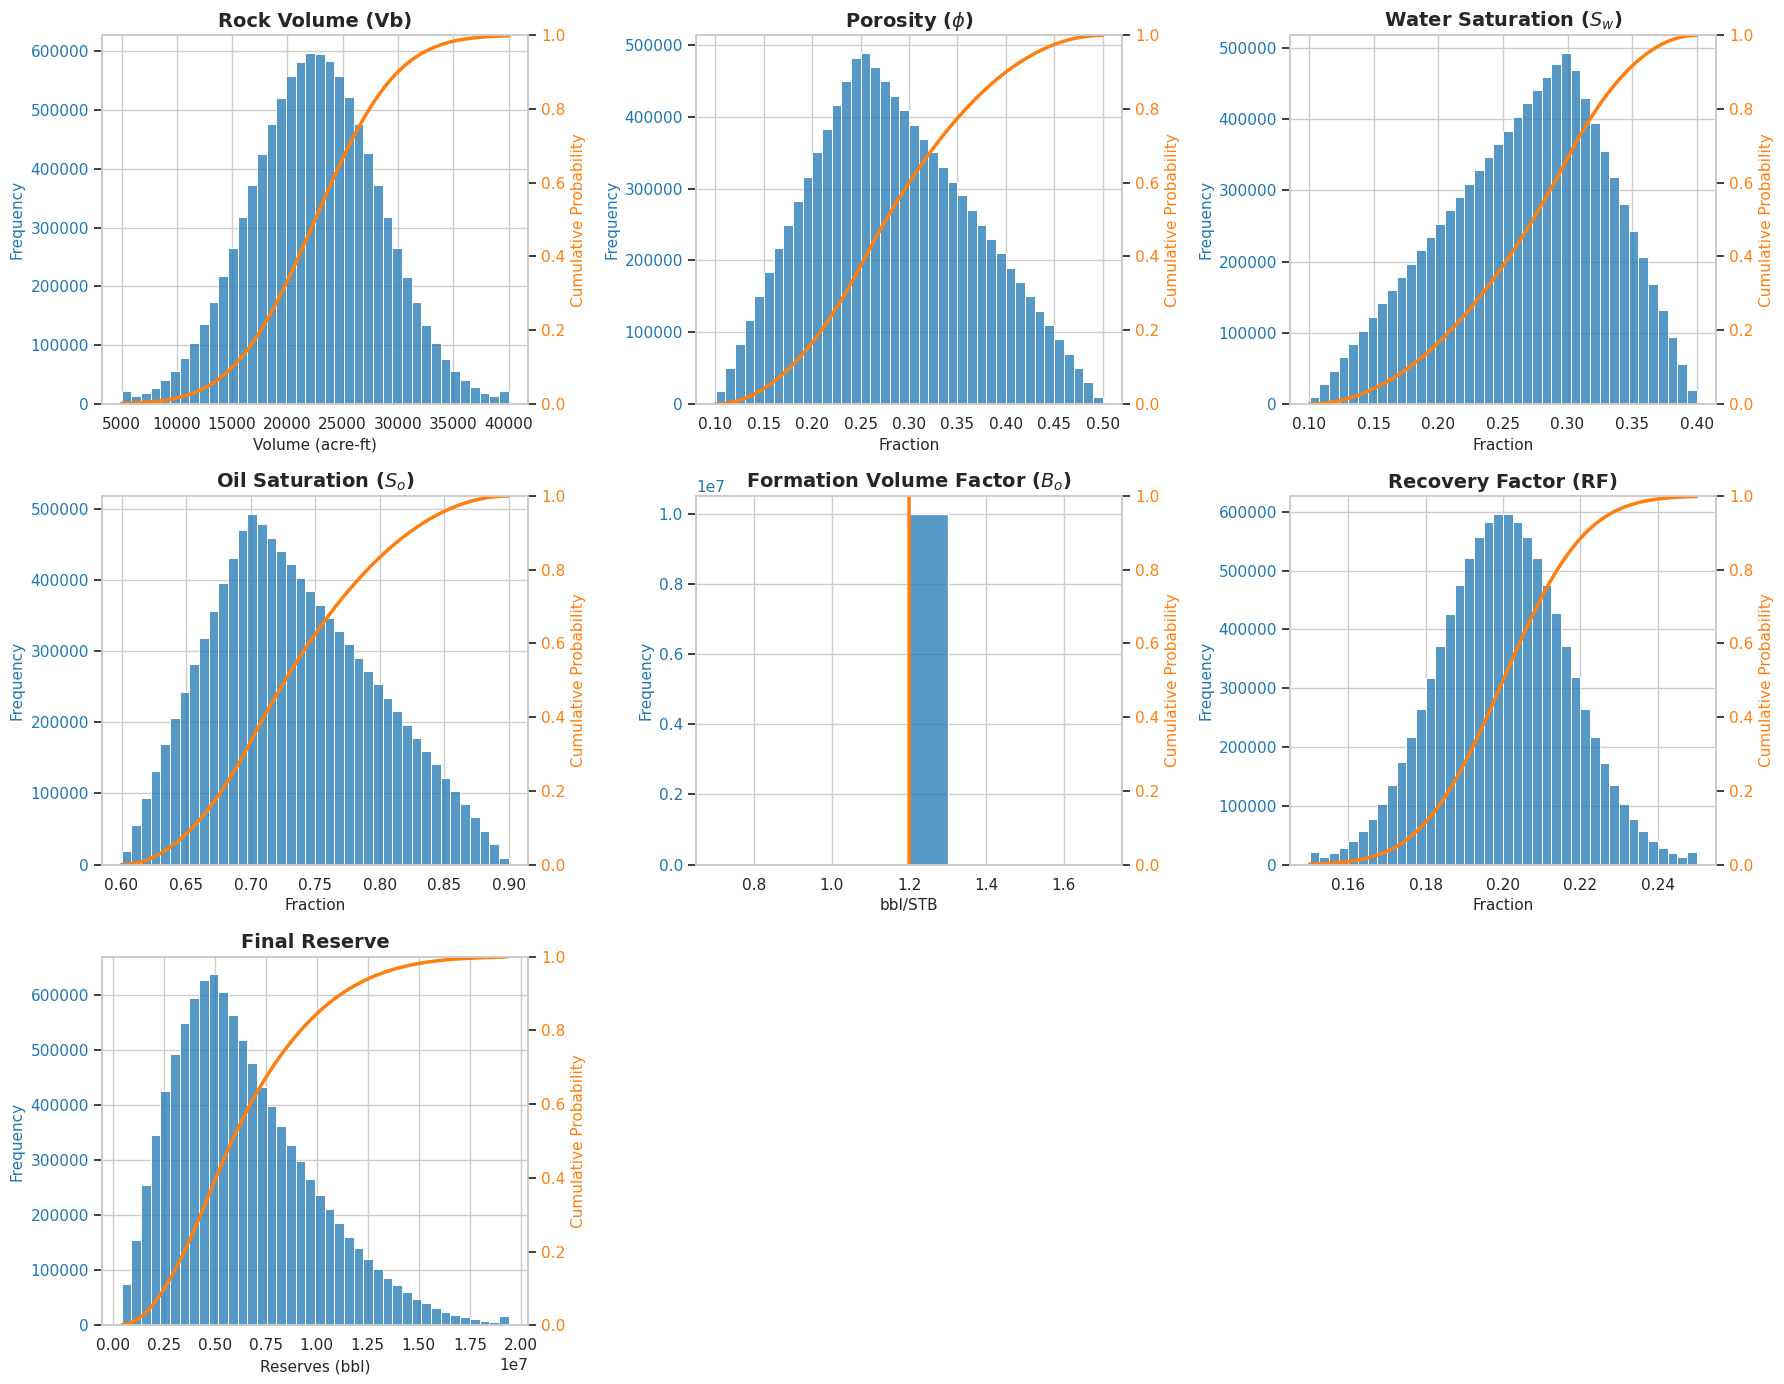

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 보고서용 깔끔한 스타일 적용
sns.set_theme(style="whitegrid")

# 시각화할 7개 변수에 대한 정보 (컬럼명, 그래프 제목, X축 라벨)
plot_info = [
    {'col': 'Vb', 'title': 'Rock Volume (Vb)', 'xlabel': 'Volume (acre-ft)'},
    {'col': 'phi', 'title': 'Porosity ($\phi$)', 'xlabel': 'Fraction'},
    {'col': 'Sw', 'title': 'Water Saturation ($S_w$)', 'xlabel': 'Fraction'},
    {'col': 'So', 'title': 'Oil Saturation ($S_o$)', 'xlabel': 'Fraction'},
    {'col': 'Bo', 'title': 'Formation Volume Factor ($B_o$)', 'xlabel': 'bbl/STB'},
    {'col': 'RF', 'title': 'Recovery Factor (RF)', 'xlabel': 'Fraction'},
    {'col': 'RESERVE', 'title': 'Final Reserve', 'xlabel': 'Reserves (bbl)'}
]

# 3행 3열의 그래프 그리드 생성 (총 9칸 중 7칸 사용)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten() # 2차원 배열을 1차원으로 펴서 반복문 쓰기 쉽게 만듦

# 각 변수별로 그래프 그리기 반복
for i, info in enumerate(plot_info):
    ax1 = axes[i]
    col = info['col']
    
    # 1. 히스토그램 (왼쪽 Y축)
    # Bo는 상수(1.2)이므로 막대가 하나만 나오게 됨. 나머지는 40개의 구간(bins)으로 분할
    bins_count = 10 if col == 'Bo' else 40 
    sns.histplot(df[col], bins=bins_count, color="#1f77b4", edgecolor='white', ax=ax1)
    
    ax1.set_title(info['title'], fontsize=14, fontweight='bold')
    ax1.set_xlabel(info['xlabel'], fontsize=11)
    ax1.set_ylabel('Frequency', color="#1f77b4", fontsize=11)
    ax1.tick_params(axis='y', labelcolor="#1f77b4")
    
    # 2. 누적 확률 분포 CDF (오른쪽 Y축)
    ax2 = ax1.twinx()
    sns.ecdfplot(df[col], color="#ff7f0e", linewidth=2.5, ax=ax2)
    ax2.set_ylabel('Cumulative Probability', color="#ff7f0e", fontsize=11)
    ax2.tick_params(axis='y', labelcolor="#ff7f0e")
    ax2.set_ylim(0, 1.0) # 0% ~ 100% (0.0 ~ 1.0) 고정
    ax2.grid(False) # 이중 축 그리드 겹침 방지

# 7개의 그래프만 그리므로, 남는 2개의 빈 그래프 캔버스는 삭제
for j in range(len(plot_info), len(axes)):
    fig.delaxes(axes[j])

# 그래프 간의 간격 자동 조절 (글자 겹침 방지)
plt.tight_layout()

# 고해상도로 이미지 저장 (보고서 삽입용)
# plt.savefig('monte_carlo_dashboard.png', dpi=300, bbox_inches='tight')

# 화면에 출력
plt.show()

In [3]:
p90 = df['RESERVE'].quantile(0.9)

# Format to 2 decimal places in scientific notation, then replace the 'e'
p90_a = f"{p90:.2e}".replace("e+0", " x 10^")

print(f"The P90 reserve is estimated at {p90_a} barrels.")

The P90 reserve is estimated at 1.12 x 10^7 barrels.


In [4]:
p50 = df['RESERVE'].quantile(0.5)

# Format to 2 decimal places in scientific notation, then replace the 'e'
p50_a = f"{p50:.2e}".replace("e+0", " x 10^")

print(f"The P50 reserve is estimated at {p50_a} barrels.")

The P50 reserve is estimated at 5.84 x 10^6 barrels.


In [5]:
p10 = df['RESERVE'].quantile(0.1)

# Format to 2 decimal places in scientific notation, then replace the 'e'
p10_a = f"{p10:.2e}".replace("e+0", " x 10^")

print(f"The P10 reserve is estimated at {p10_a} barrels.")

The P10 reserve is estimated at 2.53 x 10^6 barrels.
